# Djinni NLP Jobs Classifier
Solving a multi-class classification problem using NLP techniques based on the description of the job.
Comparing TF-IDF + Logistic Regression, Zero-shot BERT, and Fine-tuned DistilBERT.

**Dataset:** [lang-uk/recruitment-dataset-job-descriptions-ukrainian](https://huggingface.co/datasets/lang-uk/recruitment-dataset-job-descriptions-ukrainian)  
**Size:** 27,461 job postings | **Language:** Ukrainian | **Source:** Djinni

## 2. Loading Data & Imports

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
from collections import Counter

In [2]:
ds = load_dataset("lang-uk/recruitment-dataset-job-descriptions-ukrainian")
df = ds["train"].to_pandas()

## 3. Data analysis & preprocessing

In [3]:
print(df.shape)
df.head()

(27461, 10)


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__
0,1c developer,Компанія співпрацює з такими лідерами фарма і...,AboutHR,2y,Other,None,2021-06-01T00:00:00+03:00,uk,0e8d1ddb-b002-53c2-a761-20406026f153,0
1,1C developer,"IT компанія “Нова Пошта Діджитал”, що входить ...",Nova Poshta Digital,3y,Other,None,2023-03-01T00:00:00+02:00,uk,3f65951b-c5c3-5472-a39b-6bbf516addc1,1
2,1C developer,Вимоги до успішного кандидата:\r\n— Програміст...,Zakaz.ua,3y,Other,None,2022-02-01T00:00:00+02:00,uk,741d9555-9324-54ca-af5b-de4887b0f978,2
3,1C developer,ОККО запрошує стати частиною потужної команди ...,OKKO Group,3y,Other,None,2021-07-01T00:00:00+03:00,uk,5002f118-575e-5325-83c5-8075e5554bdf,3
4,1C Developer,**Everad** — міжнародна CPA-мережа з прямим ре...,Everad,3y,Other,None,2023-04-01T00:00:00+03:00,uk,70a9a45b-302f-59a5-a4e1-ee0da427a5f1,4


In [4]:
df['Primary Keyword'].value_counts()

Primary Keyword
Marketing            3562
Other                2436
JavaScript           2308
PHP                  1600
Sales                1165
QA                   1090
Design               1036
Business Analyst     1007
Project Manager      1002
HR                    930
DevOps                859
.NET                  783
Support               733
Sysadmin              726
Java                  723
Node.js               680
Python                636
QA Automation         546
Android               480
Product Manager       478
C++                   403
SEO                   386
Recruiter             374
Artist                354
Data Analyst          341
iOS                   339
Data Science          319
SQL                   315
Lead Generation       308
Unity                 260
Security              239
Lead                  192
Technical Writing     187
Golang                166
Ruby                  155
Data Engineer         154
Flutter               106
Scala                 

In [5]:
# we drop uninformative columns and delete rows, with primary key of low distribution

keys_to_drop = ['C#', 'Rust', 'Scrum Master', 'Salesforce', 'Scala', 'Other']
df = df[~df['Primary Keyword'].isin(keys_to_drop)]
df = df.drop(columns=['id', '__index_level_0__', 'Published', 'Long Description_lang'])

In [6]:
print(df.shape)
df['Primary Keyword'].value_counts()

(24942, 6)


Primary Keyword
Marketing            3562
JavaScript           2308
PHP                  1600
Sales                1165
QA                   1090
Design               1036
Business Analyst     1007
Project Manager      1002
HR                    930
DevOps                859
.NET                  783
Support               733
Sysadmin              726
Java                  723
Node.js               680
Python                636
QA Automation         546
Android               480
Product Manager       478
C++                   403
SEO                   386
Recruiter             374
Artist                354
Data Analyst          341
iOS                   339
Data Science          319
SQL                   315
Lead Generation       308
Unity                 260
Security              239
Lead                  192
Technical Writing     187
Golang                166
Ruby                  155
Data Engineer         154
Flutter               106
Name: count, dtype: int64

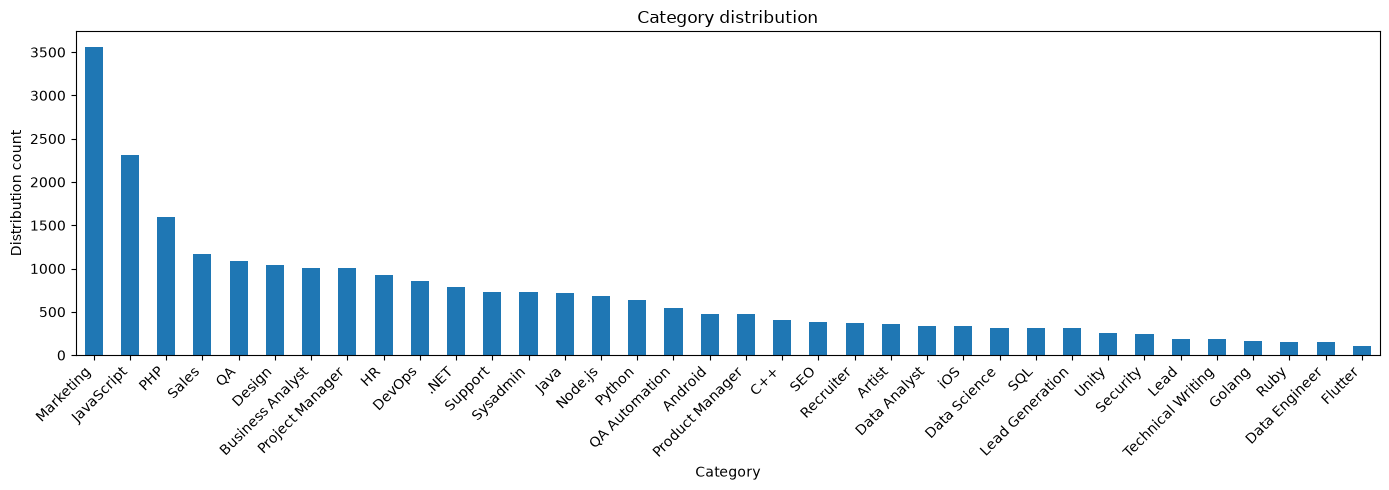

In [7]:
df['Primary Keyword'].value_counts().plot(kind='bar', figsize=(14, 5))
plt.title('Category distribution')
plt.xlabel('Category')
plt.ylabel('Distribution count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
df['Clean_description'] = (df['Long Description']
                           .str.replace(r'[\r\n\t]', " ", regex=True)
                           .str.replace(r'[^\w\s]', " ", regex=True)
                           .str.lower()
                           .str.replace(r'\s+', " ", regex=True)
                           .str.strip()
)

In [9]:
df['Clean_description'].head()

5     алло національний маркетплейс що об єднує в ек...
8     ми формуємо команду однодумців задаємо темп дл...
10    шукаємо досвідченого програміста 1с до нашої к...
12    привіт давай знайомитись ми компанія венбест в...
24    шукаємо програміста 1с на часткову проектну за...
Name: Clean_description, dtype: object

In [10]:
# load ukrainian dataset and lemmatizing
nlp = spacy.load("uk_core_news_sm")

custom_stopwords = {
    'робота', 'досвід', 'команда', 'компанія', 'можливість', 'пропонувати',
    'шукати', 'кандидат', 'відпустка', 'оплачуваний', 'графік', 'корпоративний',
    'офіс', 'рівень', 'новий', 'робочий', 'вимога', 'обов', 'підтримка',
    'участь', 'плюс', 'пошук', 'and', 'the', 'проект', 'продукт', 'процес'
}

def lemmatize(texts):
    lemmatized = []
    for doc in nlp.pipe(texts, batch_size=512, disable=['parser', 'ner']):
        tokens = [token.lemma_ for token in doc 
                  if not token.is_stop 
                  and len(token.lemma_) > 2
                  and token.lemma_ not in custom_stopwords]
        lemmatized.append(" ".join(tokens))
    return lemmatized

df['Lemmatized'] = lemmatize(df['Clean_description'])

In [11]:
df['Lemmatized'].head()

5     національний маркетплейс єднує екосистема allo...
8     формувати однодумець задавати темп розвиток ст...
10    досвідчений програміст розробник основний завд...
12    привіт давати знайомитись венбест визнаний лід...
24    програміст частковий проектний зайнятість очік...
Name: Lemmatized, dtype: object

In [12]:
# check most common words to use them as stopwords, as they dont help in classifiyng
all_words = " ".join(df['Lemmatized']).split()
word_freq = Counter(all_words)
word_freq.most_common(50)

[('знання', 28080),
 ('розробка', 27194),
 ('працювати', 22893),
 ('система', 17336),
 ('клієнт', 16358),
 ('навичка', 15978),
 ('розуміння', 15324),
 ('англійський', 14572),
 ('розвиток', 13546),
 ('дані', 11947),
 ('мова', 11933),
 ('завдання', 11821),
 ('створення', 11797),
 ('вміння', 11771),
 ('бізнес', 11771),
 ('технічний', 11481),
 ('рішення', 11113),
 ('професійний', 9978),
 ('аналіз', 9481),
 ('тестування', 9400),
 ('день', 9371),
 ('результат', 9061),
 ('навчання', 8529),
 ('язки', 8072),
 ('курс', 7874),
 ('with', 7663),
 ('основний', 7642),
 ('проєкт', 7573),
 ('мати', 7530),
 ('додаток', 7526),
 ('технологія', 7488),
 ('задача', 7449),
 ('різний', 7435),
 ('гнучкий', 7352),
 ('лікарняний', 7310),
 ('управління', 7145),
 ('користувач', 7100),
 ('розробник', 7011),
 ('україна', 6903),
 ('інструмент', 6573),
 ('платформа', 6546),
 ('великий', 6507),
 ('сервіс', 6503),
 ('ринок', 6501),
 ('experience', 6483),
 ('забезпечення', 6291),
 ('google', 6240),
 ('intermediate', 6238)

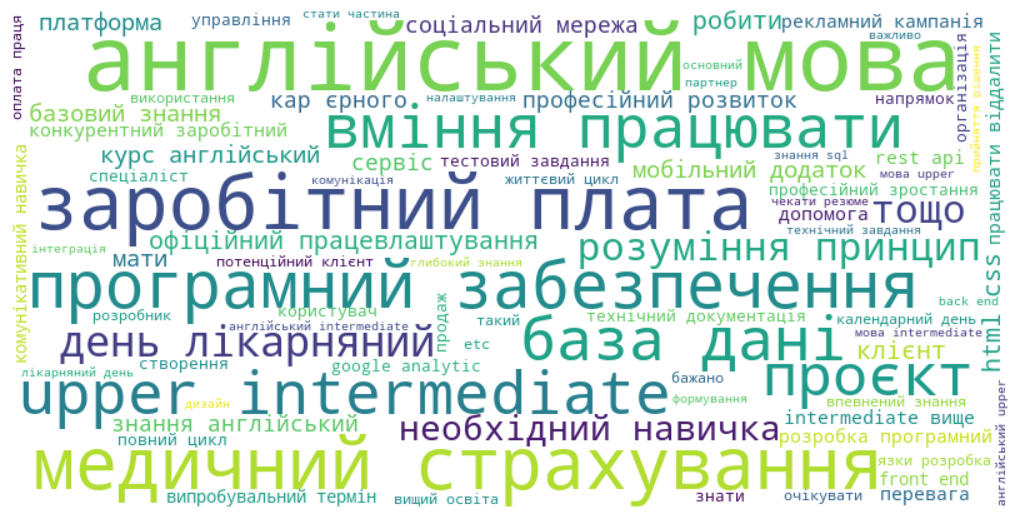

In [13]:
text_data = " ".join(item for item in df['Lemmatized'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text_data)
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad=0) 
plt.show()

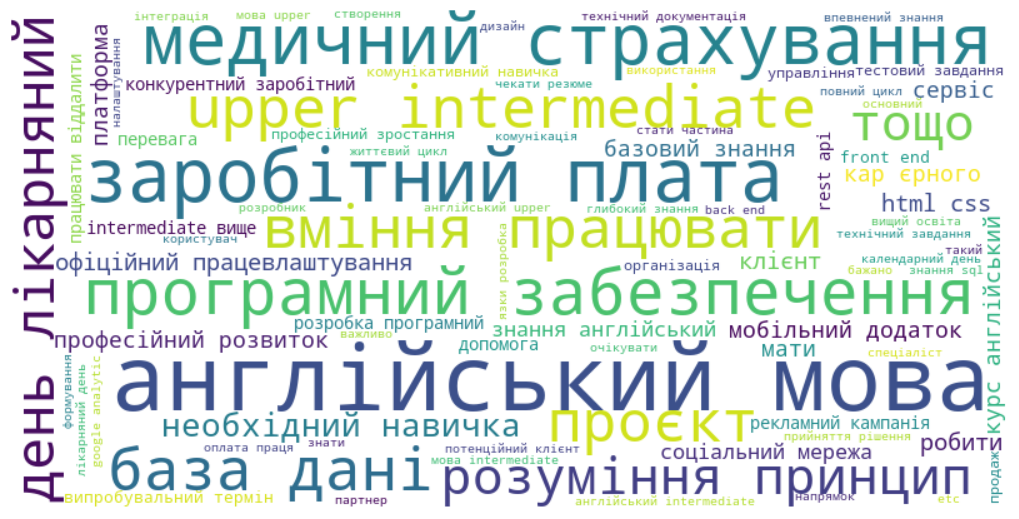

In [14]:
text_data = " ".join(item for item in df['Lemmatized'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text_data)
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad=0) 
plt.show()

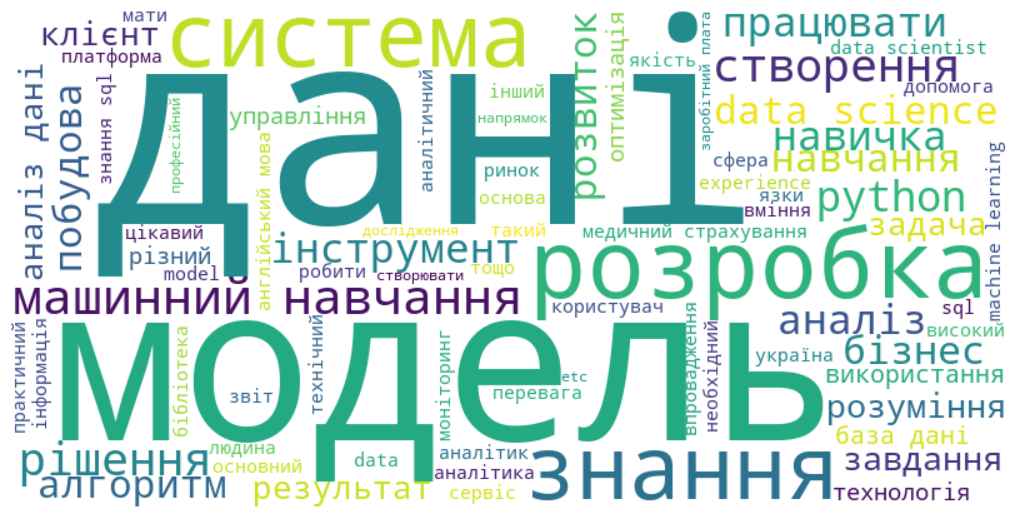

In [15]:
text_data_ds = " ".join(
    df[df['Primary Keyword'] == 'Data Science']['Lemmatized'].astype(str)
)
wordcloud_ds = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text_data_ds)
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud_ds, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad=0) 
plt.show()

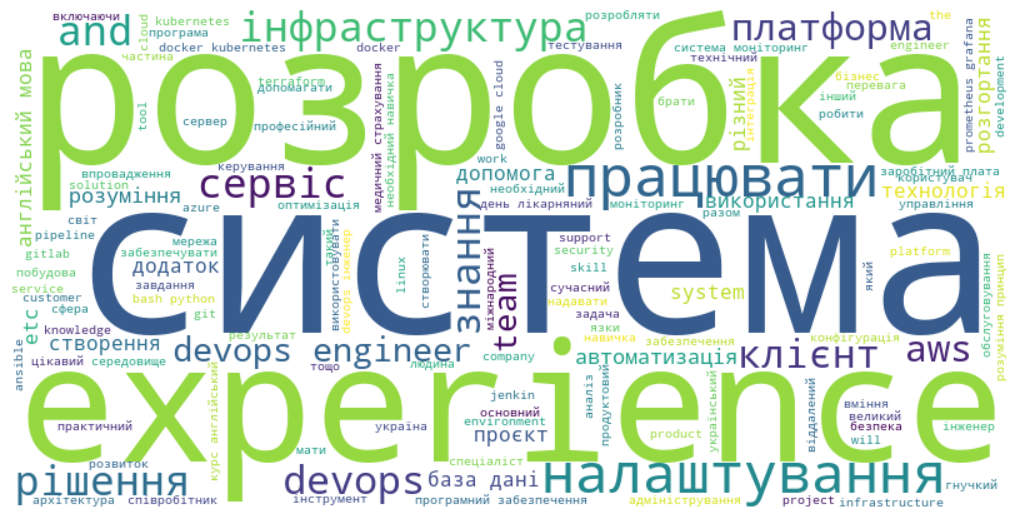

In [16]:
text_data_dops = " ".join(
    df[df['Primary Keyword'] == 'DevOps']['Lemmatized'].astype(str)
)
wordcloud_dops = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text_data_dops)
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud_dops, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad=0) 
plt.show()

In [20]:
# saving dataframe for modeling
df[['Clean_description', 'Lemmatized', 'Primary Keyword']].to_csv('../data/djinni_processed.csv', index=False)